## Model Training Tracked with Mlflow


In [21]:
# check if everything here is needed
import mlflow
from mlflow import keras
from mlflow.models import infer_signature

from helper_functions import * 

import matplotlib.pyplot as plt
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from sklearn.metrics import mean_squared_error
from keras.models import load_model

# Extract features from the test data
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score, mean_absolute_error

from mlflow.models import infer_signature

In [22]:
import os
# setting up credentials for storing the model
os.environ["AWS_ACCESS_KEY_ID"] = "eITEO5kyE7hccuy7UTHv"
os.environ["AWS_SECRET_ACCESS_KEY"] = "5KBCscit30Z70bSVGIMvMBBoqV8ydn232o2MW9RA"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = f"http://172.1.0.12:2000"

In [23]:
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")
run = mlflow.start_run(run_name='LSTM_Model_Training')

 # create a new experiment (do not replace)
#s3_bucket = "mlflow-models"  # replace this value
#mlflow.create_experiment(expr_name, s3_bucket)
#mlflow.set_experiment("Default")

## Data Prep

In [24]:
def data_prep(file_path):
    # Data preperation
    lstm_data = pd.read_csv(file_path)

    #print(lstm_data)
    lstm_data = lstm_data.drop(columns=['open_price', 'high', 'low'], axis=1)

    lstm_data = process_timestamp(lstm_data)
    lstm_data = add_feature_date(lstm_data)
    #lstm_data = add_feature_lag(lstm_data, lags=[12, 168])
    lstm_data = add_holiday_feature(lstm_data)
    lstm_data = apply_cyclic_encoding(lstm_data, columms=['hour', 'day_of_week', 'month'])
    lstm_data = apply_day_of_month_encoding(lstm_data)
    lstm_data = normalize_year(lstm_data) # has to be updated yearly 
    lstm_data = apply_log_scaler(lstm_data, columns=['close_price', 'volume', 'count'])

    lstm_data = lstm_data.drop(columns=['symbol_id','hour', 'day_of_week', 'day_of_month', 'month', 'year'], axis=1)

    lstm_data = lstm_data.dropna()

    return lstm_data

In [25]:
# Data preperation
file_path = 'kraken_ohlc_hour_count.csv'
lstm_data = data_prep(file_path)

lstm_data.head(10)
#lstm_data = pd.read_csv(file_path)
#
##print(lstm_data)
#lstm_data = lstm_data.drop(columns=['open_price', 'high', 'low'], axis=1)
#
#lstm_data = process_timestamp(lstm_data)
#lstm_data = add_feature_date(lstm_data)
##lstm_data = add_feature_lag(lstm_data, lags=[12, 168])
#lstm_data = add_holiday_feature(lstm_data)
#lstm_data = apply_cyclic_encoding(lstm_data, columms=['hour', 'day_of_week', 'month'])
#lstm_data = apply_day_of_month_encoding(lstm_data)
#lstm_data = normalize_year(lstm_data) # has to be updated yearly 
#lstm_data = apply_log_scaler(lstm_data, columns=['close_price', 'volume', 'count'])
#
#lstm_data = lstm_data.drop(columns=['bucket','symbol_id','hour', 'day_of_week', 'day_of_month', 'month', 'year'], axis=1)
#
#lstm_data = lstm_data.dropna()
#
#lstm_data.head(100)

#cycle_length = get_distinct_count(data, 'hour')
#lstm_data['hour_sin'] = lstm_data['hour'].apply(lambda x: encode_cyclic_feature(x, cycle_length)).astype(float)

,bucket,close_price,volume,count,is_weekend,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,month_cos,month_sin,day_of_month_sin,day_of_month_cos,year_normalized
0,2015-08-07 14:00:00+00:00,1.386294,4.417120,1.098612,0,0,-8.660254e-01,-0.500000,-0.900969,-0.433884,-0.5,-0.866025,0.937752,0.347305,0.0
1,2015-08-07 15:00:00+00:00,1.386294,0.000000,0.000000,0,0,-7.071068e-01,-0.707107,-0.900969,-0.433884,-0.5,-0.866025,0.937752,0.347305,0.0
2,2015-08-07 16:00:00+00:00,1.386294,0.000000,0.000000,0,0,-5.000000e-01,-0.866025,-0.900969,-0.433884,-0.5,-0.866025,0.937752,0.347305,0.0
3,2015-08-07 17:00:00+00:00,1.386294,3.762903,1.098612,0,0,-2.588190e-01,-0.965926,-0.900969,-0.433884,-0.5,-0.866025,0.937752,0.347305,0.0
4,2015-08-07 18:00:00+00:00,1.386294,0.000000,0.000000,0,0,-1.836970e-16,-1.000000,-0.900969,-0.433884,-0.5,-0.866025,0.937752,0.347305,0.0
5,2015-08-07 19:00:00+00:00,1.386294,0.000000,0.000000,0,0,2.588190e-01,-0.965926,-0.900969,-0.433884,-0.5,-0.866025,0.937752,0.347305,0.0
6,2015-08-07 20:00:00+00:00,1.386294,0.000000,0.000000,0,0,5.000000e-01,-0.866025,-0.900969,-0.433884,-0.5,-0.866025,0.937752,0.347305,0.0
7,2015-08-07 21:00:00+00:00,1.386294,0.000000,0.000000,0,0,7.071068e-01,-0.707107,-0.900969,-0.433884,-0.5,-0.866025,0.937752,0.347305,0.0
8,2015-08-07 22:00:00+00:00,1.386294,0.000000,0.000000,0,0,8.660254e-01,-0.500000,-0.900969,-0.433884,-0.5,-0.866025,0.937752,0.347305,0.0
9,2015-08-07 23:00:00+00:00,1.386294,0.000000,0.000000,0,0,9.659258e-01,-0.258819,-0.900969,-0.433884,-0.5,-0.866025,0.937752,0.347305,0.0


In [26]:
def create_sequences_np(data, features, lookback):
    data_array = data[features].to_numpy()
    X, y = [], []
    for i in range(lookback, len(data_array)):
        X.append(data_array[i-lookback:i])
        y.append(data_array[i, data.columns.get_loc('close_price')])
    return np.array(X), np.array(y)

#'close_lag12', 'close_lag168', 

features = ['close_price', 'volume', 'is_weekend', 
            'is_holiday', 'hour_cos', 'hour_sin', 'day_of_week_cos', 
            'day_of_week_sin', 'month_cos', 'month_sin', 
            'day_of_month_sin', 'day_of_month_cos', 'year_normalized']

lookback = 12
X, y = create_sequences_np(lstm_data, features, lookback)

## Model Training

In [27]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

n_features = len(features)  # Number of features used
epochs = 15
units_lstm_1 = 50
units_lstm_2 = 50
dropout_layer_1 = 0.2
dropout_layer_2 = 0.2

return_sequences_lstm_1 = True
return_sequences_lstm_2 = False

dense_units = 1 

optimizer = 'adam'
loss = 'mean_squared_error'

training_validation_split = 0.8

batch_size = 32

mlflow.log_param('lookback', lookback)
mlflow.log_param('n_features', n_features)
mlflow.log_param('features', features)
mlflow.log_param('epochs', epochs)
mlflow.log_param('units_lstm_1', units_lstm_1)
mlflow.log_param('units_lstm_2', units_lstm_2)
mlflow.log_param('return_sequences_lstm', return_sequences_lstm_1)
mlflow.log_param('optimizer', optimizer)
mlflow.log_param('loss', loss)
mlflow.log_param('training_validation_split', training_validation_split)
mlflow.log_param('batch_size', batch_size)


# LSTM model
model = Sequential()
model.add(LSTM(units=units_lstm_1,return_sequences=return_sequences_lstm_1, input_shape=(lookback, n_features))) # 1
model.add(Dropout(dropout_layer_1))
model.add(LSTM(units=units_lstm_1, return_sequences=return_sequences_lstm_2)) # 2
model.add(Dropout(dropout_layer_2))
model.add(Dense(units=dense_units))

model.compile(optimizer=optimizer, loss=loss)

# split point at 20 percent 
split_idx = int(len(X) * training_validation_split)

# validation set with the last 20 percent of the dataset 
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

# maybe 43 epochs seems to have a good loss 
model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val))


Epoch 1/15
1785/1785 [==============================] - 12s 6ms/step - loss: 2.0564 - val_loss: 0.9255
Epoch 2/15
1785/1785 [==============================] - 9s 5ms/step - loss: 1.6447 - val_loss: 0.9100
Epoch 3/15
1785/1785 [==============================] - 9s 5ms/step - loss: 1.6154 - val_loss: 1.0766
Epoch 4/15
1785/1785 [==============================] - 9s 5ms/step - loss: 1.5884 - val_loss: 1.0290
Epoch 5/15
1785/1785 [==============================] - 10s 5ms/step - loss: 1.5747 - val_loss: 0.9460
Epoch 6/15
1785/1785 [==============================] - 10s 6ms/step - loss: 1.5518 - val_loss: 0.9345
Epoch 7/15
1785/1785 [==============================] - 10s 6ms/step - loss: 1.5411 - val_loss: 0.9825
Epoch 8/15
1785/1785 [==============================] - 9s 5ms/step - loss: 1.5263 - val_loss: 1.0389
Epoch 9/15
1785/1785 [==============================] - 8s 5ms/step - loss: 1.5076 - val_loss: 0.9419
Epoch 10/15
1785/1785 [==============================] - 9s 5ms/step - loss: 1

In [28]:
## load non-training data: + 12hour lookback 

test_file_path = 'kraken_ohlc_hour_count_unseen.csv'

# Data preperation
test_lstm = data_prep(test_file_path)
original_lstm_test = pd.read_csv(test_file_path) 
#test_lstm.copy()
#print(lstm_data)
#test_lstm = test_lstm.drop(columns=['open_price', 'high', 'low'], axis=1)
#
#test_lstm = process_timestamp(test_lstm)
#test_lstm = add_feature_date(test_lstm)
##lstm_data = add_feature_lag(lstm_data, lags=[12, 168])
#test_lstm = add_holiday_feature(test_lstm)
#test_lstm = apply_cyclic_encoding(test_lstm, columms=['hour', 'day_of_week', 'month'])
#test_lstm = apply_day_of_month_encoding(test_lstm)
#test_lstm = normalize_year(test_lstm) # has to be updated yearly 
#test_lstm = apply_log_scaler(test_lstm, columns=['close_price', 'volume', 'count'])
#
#test_lstm = test_lstm.drop(columns=['bucket','symbol_id','hour', 'day_of_week', 'day_of_month', 'month', 'year'], axis=1)
#
#test_lstm = test_lstm.dropna()


test_lstm.head()

,bucket,close_price,volume,count,is_weekend,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,month_cos,month_sin,day_of_month_sin,day_of_month_cos,year_normalized
0,2023-09-29 22:00:00+00:00,7.419471,5.133628,5.241747,0,0,0.866025,-0.500000,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0
1,2023-09-29 23:00:00+00:00,7.419920,4.677774,5.099866,0,0,0.965926,-0.258819,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0
2,2023-09-30 00:00:00+00:00,7.421836,5.385064,5.379897,1,0,1.000000,0.000000,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0
3,2023-09-30 01:00:00+00:00,7.419596,4.942633,5.062595,1,0,0.965926,0.258819,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0
4,2023-09-30 02:00:00+00:00,7.421560,4.440541,4.983607,1,0,0.866025,0.500000,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0


In [29]:
test_lstm.tail()

,bucket,close_price,volume,count,is_weekend,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,month_cos,month_sin,day_of_month_sin,day_of_month_cos,year_normalized
21,2023-09-30 19:00:00+00:00,7.426900,4.975117,5.293305,1,0,0.258819,-0.965926,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0
22,2023-09-30 20:00:00+00:00,7.427352,4.186400,5.198497,1,0,0.500000,-0.866025,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0
23,2023-09-30 21:00:00+00:00,7.423992,5.975280,5.789960,1,0,0.707107,-0.707107,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0
24,2023-09-30 22:00:00+00:00,7.424303,4.573863,5.308268,1,0,0.866025,-0.500000,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0
25,2023-09-30 23:00:00+00:00,7.421782,5.072553,5.351858,1,0,0.965926,-0.258819,-1.0,6.123234e-16,1.0,-2.204364e-15,-0.207912,0.978148,0.0


1/1 [==============================] - 0s 14ms/step


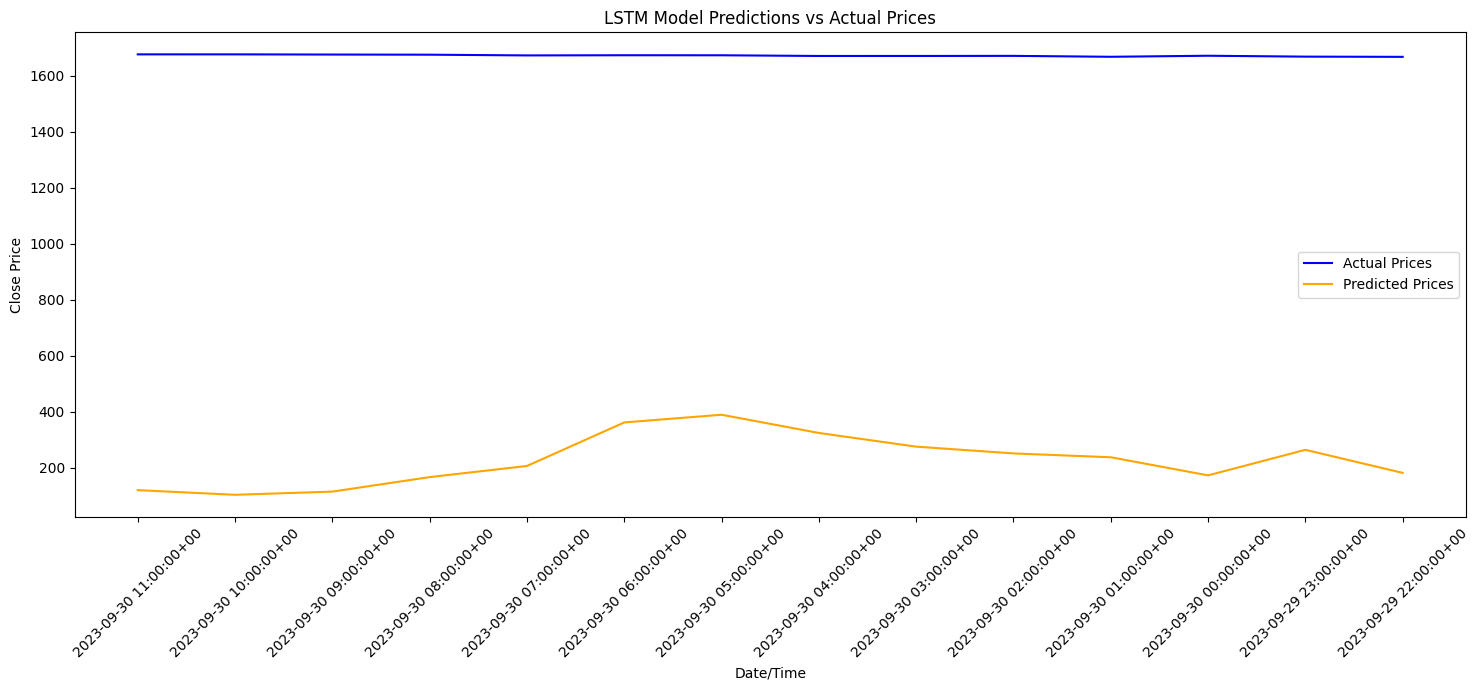

In [30]:
#features = ['close_price', 'volume', 'is_weekend', 'close_lag12', 'close_lag168',
#            'is_holiday', 'hour_cos', 'hour_sin', 'day_of_week_cos',
#            'day_of_week_sin', 'month_cos', 'month_sin',
#            'day_of_month_sin', 'day_of_month_cos', 'year_normalized']


# Start the loop to predict each next hour and collect the actual and predicted prices
predicted_prices = []
actual_prices = original_lstm_test['close_price'].values[lookback:]  # actual prices without log transformation
timestamps = original_lstm_test['bucket'].values[lookback:]  # corresponding timestamps

for i in range(lookback, len(test_lstm)):
    last_sequence = test_lstm.iloc[i-lookback:i][features].values.reshape((1, lookback, len(features)))
    predicted_log_price = model.predict(last_sequence)
    predicted_price = np.expm1(predicted_log_price)[0, 0]  # inverse log transformation
    predicted_prices.append(predicted_price)

# Convert predictions to a numpy array
predicted_prices = np.array(predicted_prices)

# Calculate the metrics
mse_value = mean_squared_error(actual_prices, predicted_prices)
mae_value = mean_absolute_error(actual_prices, predicted_prices)
rmse_value = np.sqrt(mse_value)
mape_value = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
r2_value = r2_score(actual_prices, predicted_prices)
explained_variance = explained_variance_score(actual_prices, predicted_prices)

mlflow.log_metric('mse', mse_value)
mlflow.log_metric('mae', mae_value)
mlflow.log_metric('rmse', rmse_value)
mlflow.log_metric('mape', mape_value)
mlflow.log_metric('r2', r2_value)
mlflow.log_metric('explained_variance', explained_variance)

# Plotting the results
plt.figure(figsize=(15, 7))
plt.plot(timestamps, actual_prices, label='Actual Prices', color='blue')
plt.plot(timestamps, predicted_prices, label='Predicted Prices', color='orange')
plt.xlabel('Date/Time')
plt.ylabel('Close Price')
plt.title('LSTM Model Predictions vs Actual Prices')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()  # Adjusts plot to ensure everything fits without overlapping
plt.show()


In [32]:
mlflow.set_tracking_uri('http://127.0.0.1:5000')

import datetime


unique_signature = f"{run.info.run_id}_{datetime.datetime.now()}"

mlflow.sklearn.log_model(
    sk_model=model,
    artifact_path="sklearn-model",
    signature=unique_signature,
    registered_model_name="lstm_model",
)

AttributeError: 'str' object has no attribute 'to_dict'

In [ ]:
mlflow.end_run()